In [12]:
import qtensor.states as states 
import qtensor.operators as ops
import qtensor.simulation.finiteTDVP as sim
import qtensor.simulation.updatemethod as methods
import qtensor.visualise as vis
import copy

N = 32
D = 12
initial_state = states.spin_up(N, D)
initial_state = states.random(N, 2, D, seed=1)
initial_state.left_orthogonal()
# initial_state.centralize(N//2 + 1)

# Azad params (-1, -0.5, 1.05)
J = -1
h = -0.5
g = 1.05
H = ops.tilted_ising(J, h, g, N)
H_terms = ops.extensive_as_terms(H)
Hx = ops.tilted_ising(0, 0, 1, N)
Hx_terms = ops.extensive_as_terms(Hx)
Hz = ops.tilted_ising(0, 1, 0, N)
Hz_terms = ops.extensive_as_terms(Hz)

t_final = 10
steps = 100
epsilon = 1e-5
max_iters = 4

method_l = methods.lanczos_method(epsilon=epsilon, max_iters=max_iters)
method_e = methods.exact_method()

In [13]:
state = copy.deepcopy(initial_state)
state_hist, expecs = sim.tdvp(state, H, t_final, steps, 
                              method=method_l,
                              history=True,
                              )


In [16]:
method_8 = methods.lanczos_method(epsilon=epsilon, max_iters=8)
state = copy.deepcopy(initial_state)
state8_hist, expecs8 = sim.tdvp(state, H, t_final, steps, 
                              method=method_8,
                              history=True,
                              )


In [14]:
state_e = copy.deepcopy(initial_state)
state_e_hist, expecs_e = sim.tdvp(state_e, H, t_final, steps, 
                              method=method_e,
                              history=True,
                              )


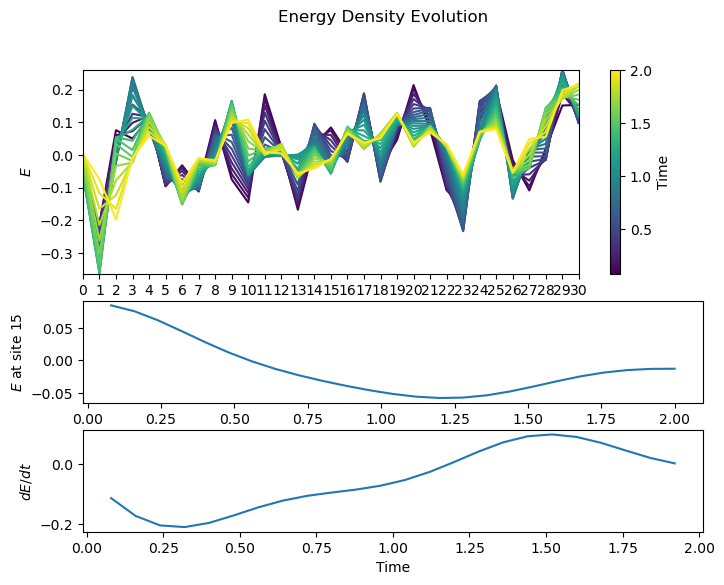

In [4]:
block=1
fig, ax = vis.plot_energy_density_evolution(state_hist, H_terms, t_f=t_final, block_len=block)
# vis.plot_entropy_evolution(state_hist, t_f=t_final, block_len=block, show_max=True)


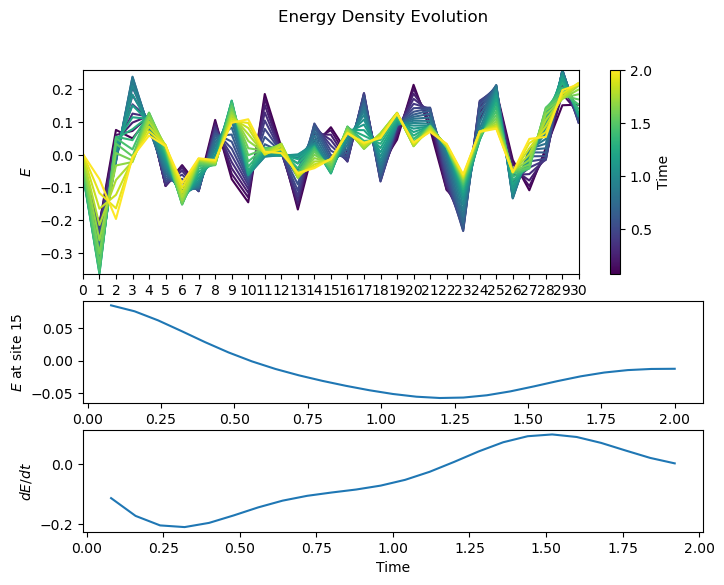

In [5]:
fig_e, ax_e = vis.plot_energy_density_evolution(state_e_hist, H_terms, t_f=t_final, block_len=block)
# vis.plot_entropy_evolution(state_hist, t_f=t_final, block_len=block, show_max=True)

<bound method Axes.legend of <Axes: title={'center': 'Lanczos vs exact \n Sites = 32, Bond dim = 12, steps = 100'}, xlabel='Time', ylabel='$ | \\langle \\psi | \\phi \\rangle | ^2 $'>>

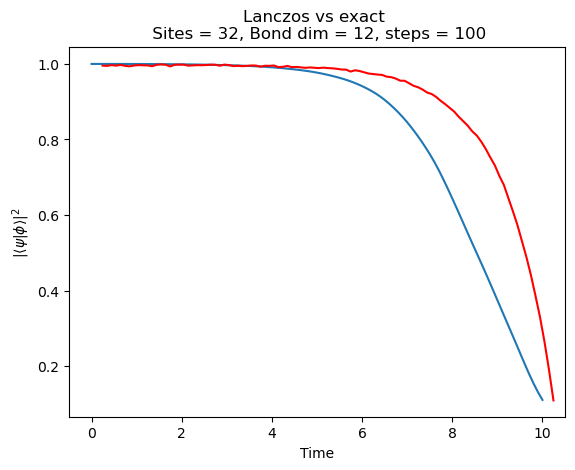

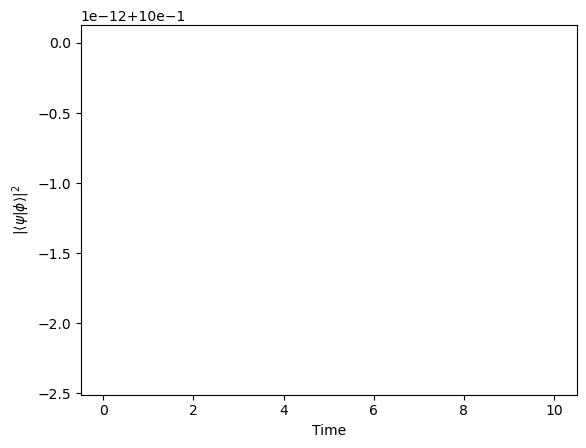

In [19]:
fig, ax = vis.overlap_evolution(state_hist, state_e_hist)
fig8, ax8 = vis.overlap_evolution(state8_hist, state_e_hist)
for artist in ax8.get_children():
    try:
        artist.remove()
        artist.set_label('8 loop')
        artist.set_color('r')
        ax.add_artist(artist)
    except Exception:
        pass
ax.set_title(f"Lanczos vs exact \n Sites = {N}, Bond dim = {D}, steps = {steps}")
ax.legend

Max possible entropy for bond dimension 16: 4.0
Max possible entropy for bond dimension 32: 5.0
Max possible entropy for bond dimension 64: 6.0


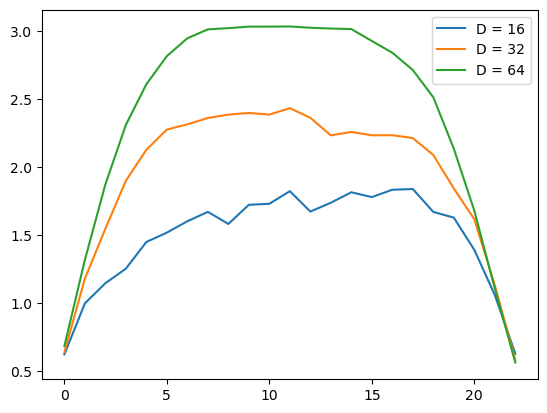

In [21]:
# Check entropy of a random state
import numpy as np
import qtensor.states as states 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)

N=24
for D in [16, 32, 64]:
    random_state = states.random(N, 2, D, seed=3)
    random_state.right_orthogonal()
    random_state.left_orthogonal()
    entropies = []
    for site in sorted(random_state.sites)[:-1]:
        ent = states.entropy(random_state, site)
        # print(f"Site: {site} ; Entropy: {ent}")
        entropies.append(ent)
    print(f"Max possible entropy for bond dimension {D}:", np.log2(D))
    ax.plot(sorted(random_state.sites)[:-1], entropies, label=f"D = {D}")
ax.legend()

In [ ]:
# Check entropy of a random state
import numpy as np
import qtensor.states as states 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)

N=24
for D in [16, 32, 64]:
    random_state = states.random(N, 2, D, seed=3)
    random_state.right_orthogonal()
    random_state.left_orthogonal()
    entropies = []
    for site in sorted(random_state.sites)[:-1]:
        ent = states.entropy(random_state, site)
        # print(f"Site: {site} ; Entropy: {ent}")
        entropies.append(ent)
    print(f"Max possible entropy for bond dimension {D}:", np.log(D))
    ax.plot(sorted(random_state.sites)[:-1], entropies, label=f"D = {D}")
ax.legend()

In [8]:
random_state[1].shape

(2, 2, 4)

## Comparing different Lanczos parameters



In [ ]:
import qtensor.states as states 
import qtensor.operators as ops
import qtensor.simulation.finiteTDVP as sim
import qtensor.simulation.updatemethod as methods
import qtensor.visualise as vis
import matplotlib.pyplot as plt
import copy

N = 16
D = 128
initial_state = states.spin_up(N, D)

# Azad params (-1, -0.5, 1.05)
J = -1
h = -0.5
g = 1.05
H = ops.tilted_ising(J, h, g, N)
H_terms = ops.extensive_as_terms(H)
Hx = ops.tilted_ising(0, 0, 1, N)
Hx_terms = ops.extensive_as_terms(Hx)
Hz = ops.tilted_ising(0, 1, 0, N)
Hz_terms = ops.extensive_as_terms(Hz)

Hz_mid = Hz_terms[N//2]

t_final = 3
steps = 30

In [ ]:
epsilon = 1e-5
iters = [4, 8, 16, 32]
centre_e = {}

fig, ax = plt.subplots(1,1)

for m in iters:
    max_iters = m
    method_l = methods.lanczos_method(epsilon=epsilon, max_iters=max_iters)
    state = copy.deepcopy(initial_state)
    state_hist, expecs = sim.tdvp(state, H, t_final, steps, 
                                method=method_l,
                                history=True,
                                )
    es = []
    for t in state_hist:
        es.append(ops.local_expect(state_hist[t], Hz_mid))
    centre_e[m] = es
    ax.plot(state_hist.keys(), es)

